# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

####  We always want to take the picture which support the background story, as in this case there is nod story is given I will pick graph for the datasize v/s  loss function - picture 1.

- I understand the importance of efficient training and cost savings for the organization. Based on Vonnegut's advice to keep it simple and be bold with cuts, I've graphed the loss function against the training data size. This graph reveals the rate at which our model learns as we increase the amount of training data. Identifying this relationship is crucial because we want our models to train quickly. Furthermore, knowing the optimal data size to achieve acceptable accuracy in the loss function allows us to avoid unnecessary data pre-processing, which is a significant expense in terms of both time and resources. Ultimately, this insight will help the organization save money and streamline our data science workflows.

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

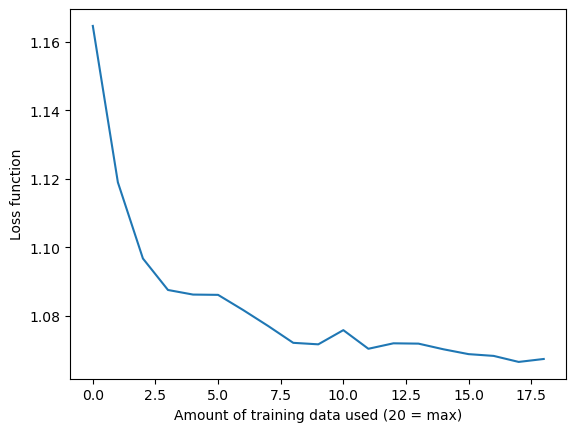

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

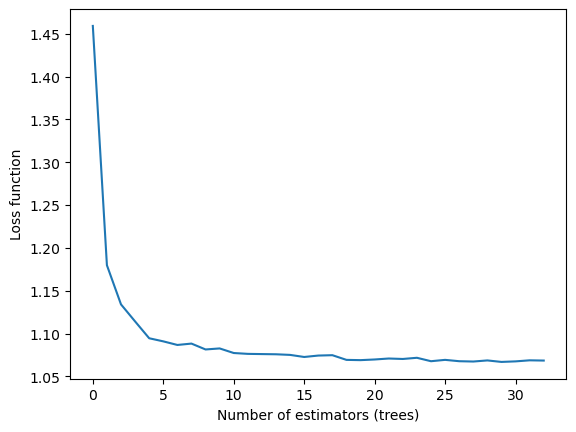

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [41]:
Cyber_Sec_DF = pd.read_csv('cybersecurity_attacks.csv')

In [42]:
Cyber_Sec_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [43]:
def get_feature_types(df):
    numerical_features = df.select_dtypes(include=['number']).columns.tolist()
    categorical_features = df.select_dtypes(exclude=['number']).columns.tolist()

    return categorical_features, numerical_features

# Example usage:
# Assuming 'df' is your Pandas DataFrame
categorical_cols, numerical_cols = get_feature_types(Cyber_Sec_DF)
print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

Categorical Features: ['Timestamp', 'Source IP Address', 'Destination IP Address', 'Protocol', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']
Numerical Features: ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']


<b>Dropping irreverent features from my domain knowledge as these information will not relevant for this EDA</b><br>
- 'Timestamp'
- 'Payload Data'
- 'User Information'
- 'Proxy Information'

In [44]:
Cyber_Sec_DF.drop(columns=[ 'Timestamp', 'Payload Data', 'User Information', 'Proxy Information'] , inplace=True)

In [45]:
for col in Cyber_Sec_DF.columns :
    if Cyber_Sec_DF[col].nunique() < 10 :
        print(col , " has unique count : " , Cyber_Sec_DF[col].nunique() )

Protocol  has unique count :  3
Packet Type  has unique count :  2
Traffic Type  has unique count :  3
Malware Indicators  has unique count :  1
Alerts/Warnings  has unique count :  1
Attack Type  has unique count :  3
Attack Signature  has unique count :  2
Action Taken  has unique count :  3
Severity Level  has unique count :  3
Network Segment  has unique count :  3
Firewall Logs  has unique count :  1
IDS/IPS Alerts  has unique count :  1
Log Source  has unique count :  2


In [46]:
devices = [
    r'Windows',
    r'Macintosh',
    r'Linux',
    r'iPhone',
    r'iPod',
    r'iPad',
    r'Android'
]

def device_identifier(user_agent):
    user_agent = user_agent.strip()
    for device in devices:
        matching = re.findall(device, user_agent, re.IGNORECASE)
        if matching:
            return matching[0]
    return 'Unknown Device'

Cyber_Sec_DF['Targeted Device'] = Cyber_Sec_DF['Device Information'].apply(device_identifier)
Cyber_Sec_DF['Targeted Device'].unique()

array(['Windows', 'Macintosh', 'Linux', 'iPhone', 'iPad', 'Android'],
      dtype=object)

In [47]:
Cyber_Sec_DF.columns

Index(['Source IP Address', 'Destination IP Address', 'Source Port',
       'Destination Port', 'Protocol', 'Packet Length', 'Packet Type',
       'Traffic Type', 'Malware Indicators', 'Anomaly Scores',
       'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken',
       'Severity Level', 'Device Information', 'Network Segment',
       'Geo-location Data', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source',
       'Targeted Device'],
      dtype='object')

In [48]:
week11_phishing_email_df =backup_df.sample(frac=1, random_state=23).reset_index(drop=True)
y = week11_phishing_email_df['Action Taken']

In [49]:
for col_name in Cyber_Sec_DF.columns:
    if(Cyber_Sec_DF[col_name].dtype == 'object'):
        Cyber_Sec_DF[col_name]= Cyber_Sec_DF[col_name].astype('category')
        Cyber_Sec_DF[col_name] = Cyber_Sec_DF[col_name].cat.codes

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy import stats
#adding the below import so we can calculate the meansquared error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, f1_score, precision_score, recall_score, classification_report, confusion_matrix


np.random.seed(0)
#let me get the target value from main dataset
backup_df = Cyber_Sec_DF.copy()
week11_phishing_email_df =backup_df.sample(frac=1, random_state=23).reset_index(drop=True)
#y = week11_phishing_email_df['Action Taken']
X = week11_phishing_email_df.drop(columns=['Action Taken','Source IP Address','Destination IP Address','Protocol'])

# let me standardize the data using standard scaler
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# test setup and config
result_df = pd.DataFrame()
random_value = [19,21,23,99]  # random value to be used for r different test to do an average at the end
no_of_iter = 10 # number iof iterations to run the test

for random_int in random_value:
	rsCV = RandomizedSearchCV(estimator = RandomForestRegressor(random_state=random_int), param_distributions = {"n_estimators": [2, 4, 16, 32,64, 90,132], "max_depth": [2, 4, 10,20, 30,50, 60]}, scoring = "neg_mean_squared_error", cv=5, n_iter=no_of_iter, random_state=random_int)
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
	rsCV.fit(X_train, y_train)
	y_pred_best = rsCV.best_estimator_.predict(X_test)
	#since the data is binary so lets round it
	y_pred_best = np.round(y_pred_best)
	corr , p_value = stats.pearsonr(y_test, y_pred_best)
    # add to  a dataframe result_df and have columns alpha, corr, p_value best_estimator, best_params, best_score, f1score, precision and recall
	row_data= pd.DataFrame({ "corr" : [corr], "p_value" : [p_value], "best_estimator":[str(rsCV.best_estimator_)], "best_params":[str(rsCV.best_params_)], "best_score":[str(rsCV.best_score_)] ,"rmse": [mean_squared_error(y_test, y_pred_best)],"f1_score": [f1_score(y_test, y_pred_best, average='weighted')]})
	result_df = pd.concat([result_df,row_data], ignore_index=True)
sorted_df_neg_mean_squared = result_df.sort_values(by='corr', ascending=False)
pd.DataFrame(sorted_df_neg_mean_squared)

c:\Users\kmisra\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
c:\Users\kmisra\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
c:\Users\kmisra\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
c:\Users\kmisra\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


,corr,p_value,best_estimator,best_params,best_score,rmse,f1_score
0,NaN,NaN,"RandomForestRegressor(max_depth=4, n_estimator...","{'n_estimators': 132, 'max_depth': 4}",-0.6686135859664681,0.666375,0.166922
1,NaN,NaN,"RandomForestRegressor(max_depth=2, n_estimator...","{'n_estimators': 16, 'max_depth': 2}",-0.6684481783263977,0.666375,0.166922
2,NaN,NaN,"RandomForestRegressor(max_depth=4, n_estimator...","{'n_estimators': 132, 'max_depth': 4}",-0.6686087270751802,0.666375,0.166922
3,NaN,NaN,"RandomForestRegressor(max_depth=4, n_estimator...","{'n_estimators': 64, 'max_depth': 4}",-0.6685996069407906,0.666375,0.166922


### Overall Analysis

- a. Random forest model

- b. perform cross validation  : The code above did CV = 5 and n_iter = 10 so it did 5 fold cross validation and 50 iterations to arrive at the results and best hyper parameters

- c. Tune hyper parameters : Best Hyper parameter observed: {'n_estimators': 90, 'max_depth': 10}

- Evaluate a performance metric : The best metric I can use is f1 score, precision and recall : 0.772, 0.782 0.763 respectively . We can work on the data derive some more temporal features and tune this model further to improve the precision score as it is below 0.78 which is not ideal. The correlation can also be improved so I will do a bit more preprocessing of the spam email data.

Over model stability is good. Even when I change the random numbers or decrease the test train split 0.2 to 0.4 I didnt see much of change. The mean square error ie 0.1654( best score) and rmse on the test data is also near the  best_score which is good



#### My expectation from a Cyber Security Prediction vs result achieved

- Correlation above 0.3 but not higher than 70% (as it may mean overfitting) / Achieved 0.45 with traingset split of 0.2 and 0.36 with training split of 0.4

- p_value as low as possible nearer to zero as that would mean statistically significant correlation without the chance of it being a fluke / Achieved very low ( 7.923 e to power -20) and near zero

- Mean Squared Error (MSE) as low as possible (best_score) / achieved 0.1944

- rmse(for test data)- Square of this value as near to MSE as possible / 0.112074

- f1 Score - Reliability of the model in the range of .7 to 0.9 / Achieved 0.72



# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

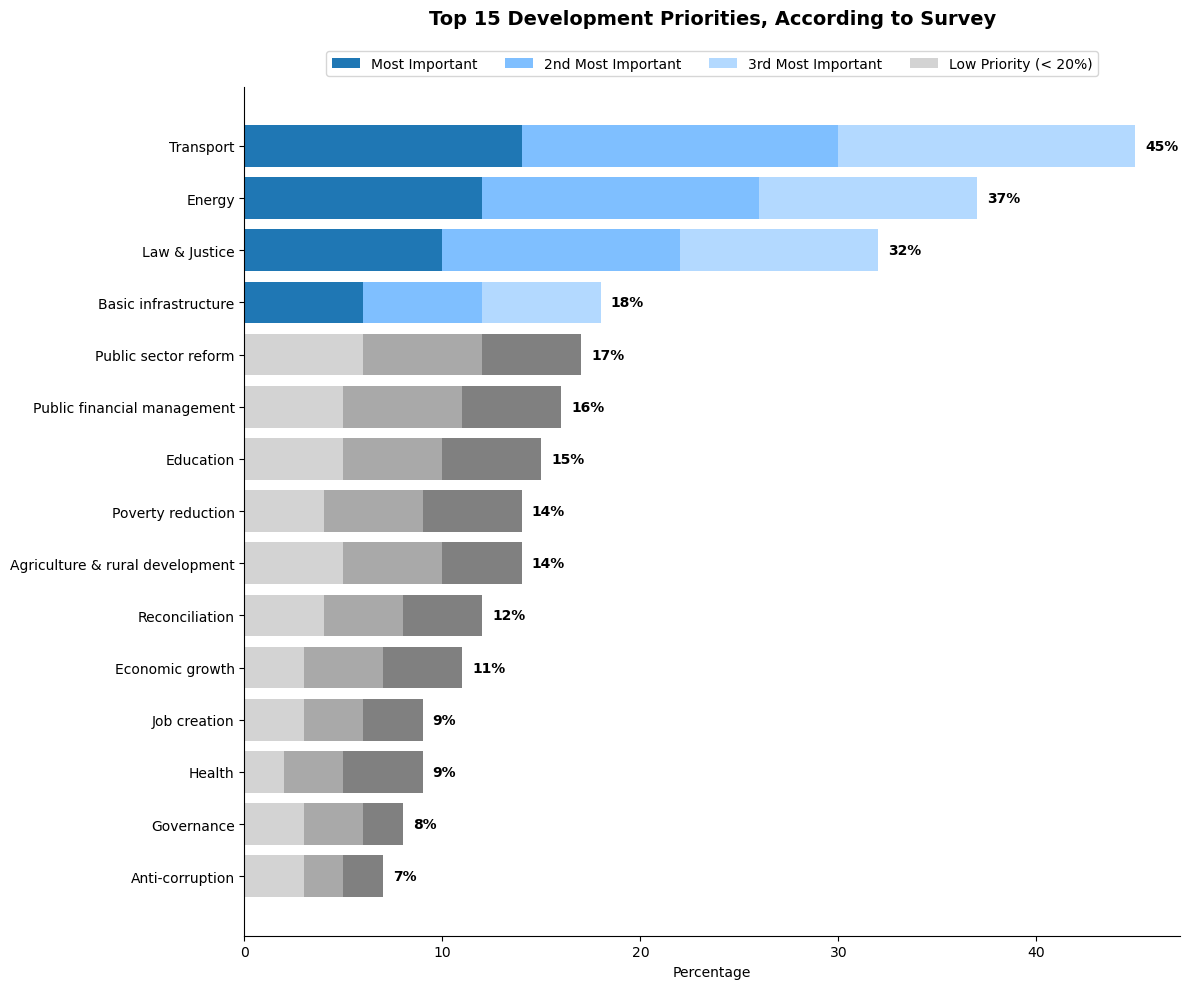

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# dev priorities identified

dev_priorities_labels = [
    'Anti-corruption', 'Governance', 'Job creation', 'Health', 'Economic growth',
    'Reconciliation', 'Poverty reduction', 'Agriculture & rural development',
    'Education', 'Public financial management', 'Public sector reform',
    'Basic infrastructure', 'Law & Justice', 'Energy', 'Transport'
]


light_blue  = '#1f77b4'
medium_blue = '#7fbfff'
darker_blue = '#b3d9ff'

# let me create data for survey plot
survey_most_important_counts = [3, 3, 3, 2, 3, 4, 4, 5, 5, 5, 6, 6, 10, 12, 14]
survey_second_important_counts = [2, 3, 3, 3, 4, 4, 5, 5, 5, 6, 6, 6, 12, 14, 16]
survey_third_important_counts = [2, 2, 3, 4, 4, 4, 5, 4, 5, 5, 5, 6, 10, 11, 15]

total_percentages = [sum(x) for x in zip(survey_most_important_counts, survey_second_important_counts, survey_third_important_counts)]


sorted_data = sorted(
    zip(dev_priorities_labels, total_percentages, survey_most_important_counts, survey_second_important_counts, survey_third_important_counts),
    key=lambda x: x[1],
    reverse=True
)


dev_priorities_sorted, total_percentages_sorted, most_important_sorted, second_important_sorted, third_important_sorted = zip(*sorted_data)


myfig= plt.figure(figsize=(12, 10))


#let me create this method as I may have to call it multiple times and dont want to commit mistake
def get_value_based_color(total_per, threshold=20 ):
	light_blue  = '#1f77b4'
	medium_blue = '#7fbfff'
	darker_blue = '#b3d9ff'
	if total_per < threshold:
		return ['lightgrey', 'darkgrey', 'grey']
	else:
		return [light_blue, medium_blue, darker_blue]

#let me reverse the order in which the graph will show so highest is on top
for i, (priority, total, most, second, third) in enumerate(zip(
    reversed(dev_priorities_sorted),
    reversed(total_percentages_sorted),
    reversed(most_important_sorted),
    reversed(second_important_sorted),
    reversed(third_important_sorted)
)):
    colors = get_value_based_color(total, 18)

    plt.barh(i, most, color=colors[0], left=0)
    plt.barh(i, second, color=colors[1], left=most)
    plt.barh(i, third, color=colors[2], left=most+second)


    plt.text(total + 0.5, i, f'{total}%', va='center', fontweight='bold')

# set label and title
plt.xlabel('Percentage')
plt.title('Top 15 Development Priorities, According to Survey', fontsize=14, fontweight='bold', pad=45)


plt.yticks(range(len(dev_priorities_sorted)), list(reversed(dev_priorities_sorted)))



legend_elements = [
    Patch(facecolor= light_blue, label='Most Important'),
    Patch(facecolor= medium_blue, label='2nd Most Important'),
    Patch(facecolor= darker_blue, label='3rd Most Important'),
    Patch(facecolor='lightgrey', label='Low Priority (< 20%)')
]

#google search showed Moving Legend Outside the Plot: Use bbox_to_anchor and loc parameters

plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4) # center aligned and 4 legend so fo col
plt.tight_layout()


plt.gca().spines['right'].set_visible(False)  # remove spines for less clutter
plt.gca().spines['top'].set_visible(False)

plt.show()